# Tallinn Restaurants — Predictive Modelling

**Objective:** Predict `Service` rating from restaurant features.  
**Approach:** Mean baseline → Ridge → LightGBM → XGBoost, evaluated with K-Fold CV and a held-out test set.

> **Note on leakage:** `Food` and `Atmosphere` are concurrent ratings — if the goal is pre-visit prediction, they must be excluded. Here we treat the task as post-hoc scoring analysis and include them as features.

---

**Sections:**
1. Imports & Configuration  
2. Data Loading  
3. Feature Engineering  
4. Feature Selection & Target  
5. Train / Test Split  
6. Preprocessing Pipeline  
7. Cross-Validated Baseline  
8. Ridge Regression  
9. LightGBM  
10. XGBoost  
11. Model Comparison  
12. Feature Importance (Gain)  
13. Residual Analysis  
14. Error Stratification  
15. Summary & Conclusions  


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, shapiro

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

SEED   = 42
TARGET = 'Service'
K_FOLDS = 5
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Data Loading

In [2]:
df = pd.read_csv('Data/restaraunts_tallinn.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df.head(3)

Shape: 97 rows × 11 columns
Memory: 0.03 MB


,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,Al Mare Grill,http://www.almarefood.ee/grill/,Mõisa tn 4,american,mid-range,3.5000,3.0000,3.1000,3.1200,59.4272,24.6557
1,Allee,https://www.alleerestoran.ee/,Kanuti 2,international,mid-range,4.0000,4.1000,3.9000,4.0400,59.4401,24.7511
2,Argentiina Lootsi,https://argentiina.ee/,Lootsi 8,argentinean,expensive,3.3000,4.3000,3.6000,3.9600,59.4408,24.7652


## 3. Feature Engineering

Two transformations applied on top of raw features:

| Transform | Why |
|---|---|
| **log1p** | Reduces right-skew in positive columns; helps linear models |
| **Rank norm `[-0.5, 0.5]`** | Monotone transform; robust to outliers; standard in quant factor research |

Both are additive — we keep the originals so the model can choose.


In [3]:
df_fe = df.copy()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Log-transform right-skewed positive columns
skewed_cols = [
    c for c in num_cols
    if c != TARGET and df[c].skew() > 1 and (df[c] > 0).all()
]
print(f'Log-transforming ({len(skewed_cols)} cols): {skewed_cols}')
for c in skewed_cols:
    df_fe[f'log_{c}'] = np.log1p(df_fe[c])

# Rank normalisation to [-0.5, 0.5]
def rank_normalize(s):
    """Rank-normalise series to [-0.5, 0.5], NaNs preserved."""
    r = s.rank(method='average', na_option='keep')
    return (r - 1) / (r.count() - 1) - 0.5

for c in num_cols:
    if c != TARGET:
        df_fe[f'rank_{c}'] = rank_normalize(df_fe[c])

print(f'Feature matrix: {df_fe.shape[1]} columns after engineering')

Log-transforming (1 cols): ['Longitude']
Feature matrix: 17 columns after engineering


## 4. Feature Selection & Target Definition

In [4]:
FEATURES = [
    c for c in df_fe.columns
    if c != TARGET and df_fe[c].dtype in [np.float64, np.int64]
]
X = df_fe[FEATURES]
y = df_fe[TARGET]

print(f'Features : {len(FEATURES)}')
print(f'Target   : {TARGET}  mean={y.mean():.3f}  std={y.std():.3f}  '
      f'range=[{y.min():.1f}, {y.max():.1f}]')

Features : 11
Target   : Service  mean=4.169  std=0.398  range=[2.6, 4.8]


## 5. Train / Test Split

**80/20 random split** — appropriate because restaurant reviews are i.i.d. (no temporal ordering in dataset). The test set is held out and never used for fitting or preprocessing decisions.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 77  |  Test: 20


## 6. Preprocessing Pipeline

**Critical:** `fit_transform` only on train; `transform` on test. Fitting on the full dataset would introduce data leakage — the test set distribution would influence scaling and imputation parameters.


In [6]:
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
], remainder='drop')

X_train_p = preprocessor.fit_transform(X_train)  # fit + transform on train only
X_test_p  = preprocessor.transform(X_test)        # transform only — no leakage
print(f'Processed shape: {X_train_p.shape}')

Processed shape: (77, 11)


## 7. Evaluation Helper + Baseline

### Metrics

| Metric | Why |
|---|---|
| **RMSE** | Primary — penalises large errors; same unit as target |
| **MAE** | Secondary — more robust to outliers; easier to interpret |
| **R²** | Proportion of variance explained |
| **Spearman ρ** | Rank correlation — measures if we correctly *order* restaurants even if absolute predictions are off |
| **Overfit gap** | `RMSE_test − RMSE_train` — large positive = overfitting |

A useful model must beat the **mean baseline** on *all* metrics.


In [7]:
def cv_score(model, X_tr, y_tr, cv=K_FOLDS):
    """Return mean ± std RMSE from K-Fold CV on training data."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    neg_mse = cross_val_score(model, X_tr, y_tr,
                               scoring='neg_mean_squared_error', cv=kf)
    rmse_scores = np.sqrt(-neg_mse)
    return rmse_scores.mean(), rmse_scores.std()


def evaluate(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Fit, cross-validate, and evaluate on hold-out. Returns metrics dict."""
    # CV on train
    cv_mean, cv_std = cv_score(model, X_tr, y_tr)

    # Final fit + hold-out eval
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    m = {
        'model'        : name,
        'CV_RMSE_mean' : cv_mean,
        'CV_RMSE_std'  : cv_std,
        'RMSE_train'   : np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        'RMSE_test'    : np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'MAE_test'     : mean_absolute_error(y_te, y_pred_te),
        'R2_test'      : r2_score(y_te, y_pred_te),
        'Spearman_test': spearmanr(y_te, y_pred_te).statistic,
    }
    m['overfit_gap'] = m['RMSE_test'] - m['RMSE_train']

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(f"  CV RMSE ({K_FOLDS}-fold) : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  RMSE train      : {m['RMSE_train']:.4f}")
    print(f"  RMSE test       : {m['RMSE_test']:.4f}  (gap: {m['overfit_gap']:+.4f})")
    print(f"  MAE  test       : {m['MAE_test']:.4f}")
    print(f"  R²   test       : {m['R2_test']:.4f}")
    print(f"  Spearman test   : {m['Spearman_test']:.4f}")
    return m


results = []
results.append(evaluate(
    DummyRegressor(strategy='mean'),
    X_train_p, y_train, X_test_p, y_test, 'Baseline (mean)'
))


────────────────────────────────────────────────────
  Baseline (mean)
────────────────────────────────────────────────────
  CV RMSE (5-fold) : 0.3956 ± 0.0919
  RMSE train      : 0.4002
  RMSE test       : 0.3813  (gap: -0.0189)
  MAE  test       : 0.2997
  R²   test       : -0.0581
  Spearman test   : nan


## 8. Ridge Regression

L2-regularised linear model. Best-case scenario for Ridge: features are correlated (Food / Atmosphere / Service are all ratings — likely correlated), and the relationship is approximately linear.

`alpha=1.0` is a sensible default; would tune with `RidgeCV` in production.



────────────────────────────────────────────────────
  Ridge
────────────────────────────────────────────────────
  CV RMSE (5-fold) : 0.1447 ± 0.0374
  RMSE train      : 0.1072
  RMSE test       : 0.0781  (gap: -0.0291)
  MAE  test       : 0.0611
  R²   test       : 0.9556
  Spearman test   : 0.9837


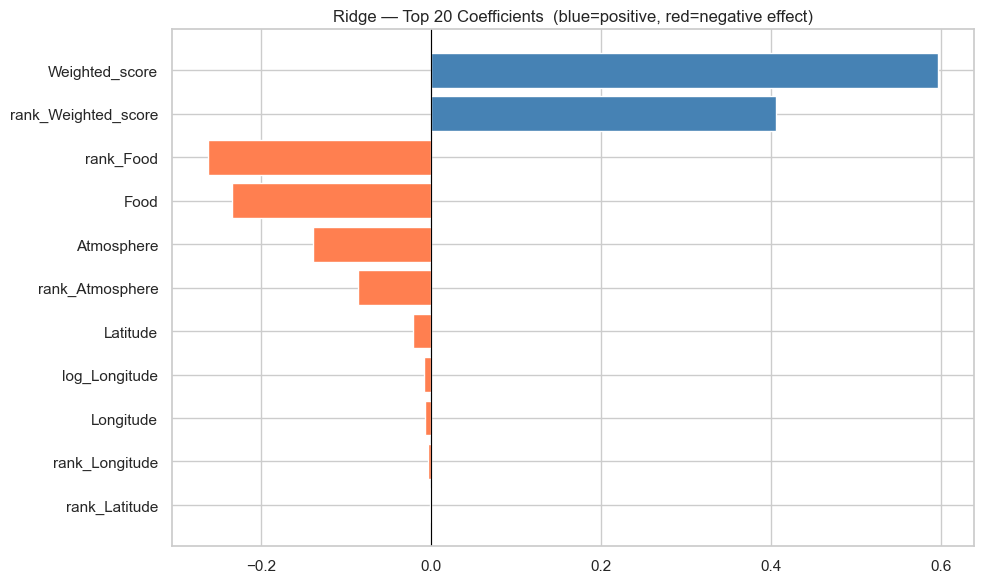

In [8]:
ridge = Ridge(alpha=1.0, random_state=SEED)
results.append(evaluate(
    ridge, X_train_p, y_train, X_test_p, y_test, 'Ridge'
))

# Coefficient plot
coef_df = pd.DataFrame({
    'feature': num_features,
    'coef'   : ridge.coef_[:len(num_features)]
}).sort_values('coef', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge — Top 20 Coefficients  (blue=positive, red=negative effect)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. LightGBM

GBDT with leaf-wise growth. Key params:

| Param | Value | Rationale |
|---|---|---|
| `num_leaves` | 64 | Moderate complexity; increase if underfitting |
| `min_child_samples` | 20 | Prevents leaves with too few observations |
| `subsample / colsample_bytree` | 0.8 | Stochastic boosting — reduces variance |
| `learning_rate` | 0.05 | Low enough for stable convergence with 500 trees |


In [9]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbose=-1
)
results.append(evaluate(
    lgb_model, X_train_p, y_train, X_test_p, y_test, 'LightGBM'
))


────────────────────────────────────────────────────
  LightGBM
────────────────────────────────────────────────────
  CV RMSE (5-fold) : 0.2702 ± 0.0479
  RMSE train      : 0.1866
  RMSE test       : 0.2558  (gap: +0.0692)
  MAE  test       : 0.2069
  R²   test       : 0.5236
  Spearman test   : 0.8298


## 10. XGBoost

Alternative GBDT — depth-wise growth, more conservative by default. Used as a cross-check against LightGBM. Consistent results across both give higher confidence in the findings.


In [10]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=0
)
results.append(evaluate(
    xgb_model, X_train_p, y_train, X_test_p, y_test, 'XGBoost'
))


────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  CV RMSE (5-fold) : 0.2553 ± 0.0635
  RMSE train      : 0.0200
  RMSE test       : 0.1444  (gap: +0.1244)
  MAE  test       : 0.1154
  R²   test       : 0.8482
  Spearman test   : 0.9480


## 11. Model Comparison

Train vs test RMSE per model. A well-behaved model has:
- Test RMSE meaningfully below baseline  
- Small overfit gap (< ~0.05 on a 1–5 scale)  
- CV RMSE ≈ test RMSE (stable generalisation)


Full Model Comparison:
                 CV_RMSE_mean  CV_RMSE_std  RMSE_train  RMSE_test  overfit_gap  MAE_test  R2_test  Spearman_test
model                                                                                                           
Baseline (mean)        0.3956       0.0919      0.4002     0.3813      -0.0189    0.2997  -0.0581            NaN
Ridge                  0.1447       0.0374      0.1072     0.0781      -0.0291    0.0611   0.9556         0.9837
LightGBM               0.2702       0.0479      0.1866     0.2558       0.0692    0.2069   0.5236         0.8298
XGBoost                0.2553       0.0635      0.0200     0.1444       0.1244    0.1154   0.8482         0.9480


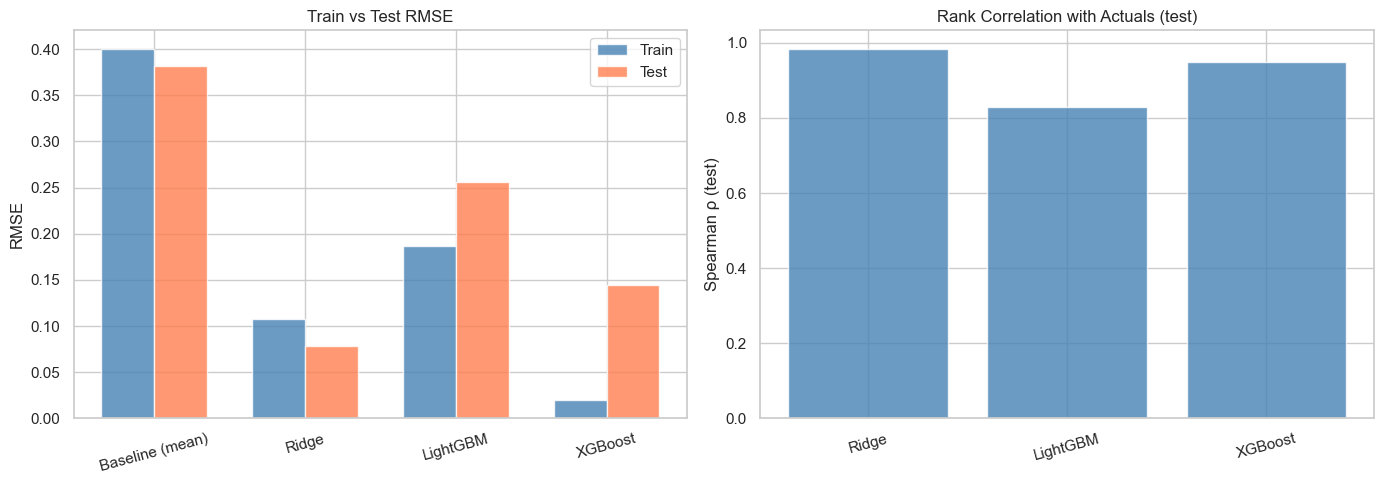

In [11]:
res_df = pd.DataFrame(results).set_index('model')
display_cols = ['CV_RMSE_mean','CV_RMSE_std','RMSE_train','RMSE_test',
                 'overfit_gap','MAE_test','R2_test','Spearman_test']
print('Full Model Comparison:')
print(res_df[display_cols].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
x = np.arange(len(res_df))
w = 0.35
axes[0].bar(x - w/2, res_df['RMSE_train'], w, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, res_df['RMSE_test'],  w, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(res_df.index, rotation=15)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Train vs Test RMSE')
axes[0].legend()

# Spearman comparison
axes[1].bar(res_df.index, res_df['Spearman_test'], color='steelblue', alpha=0.8)
axes[1].set_ylabel('Spearman ρ (test)')
axes[1].set_title('Rank Correlation with Actuals (test)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 12. Feature Importance — LightGBM (Gain)

`importance_type='gain'` reports the **total reduction in loss** attributable to each feature across all splits — more informative than split count, which favours high-cardinality features.


Top features by gain importance:
            feature  importance_pct
     Weighted_score         47.6662
rank_Weighted_score         31.6789
           Latitude          6.7124
         Atmosphere          5.1728
    rank_Atmosphere          2.3724
          Longitude          1.5805
     rank_Longitude          1.5533
               Food          1.4124
      rank_Latitude          1.3553
      log_Longitude          0.3163


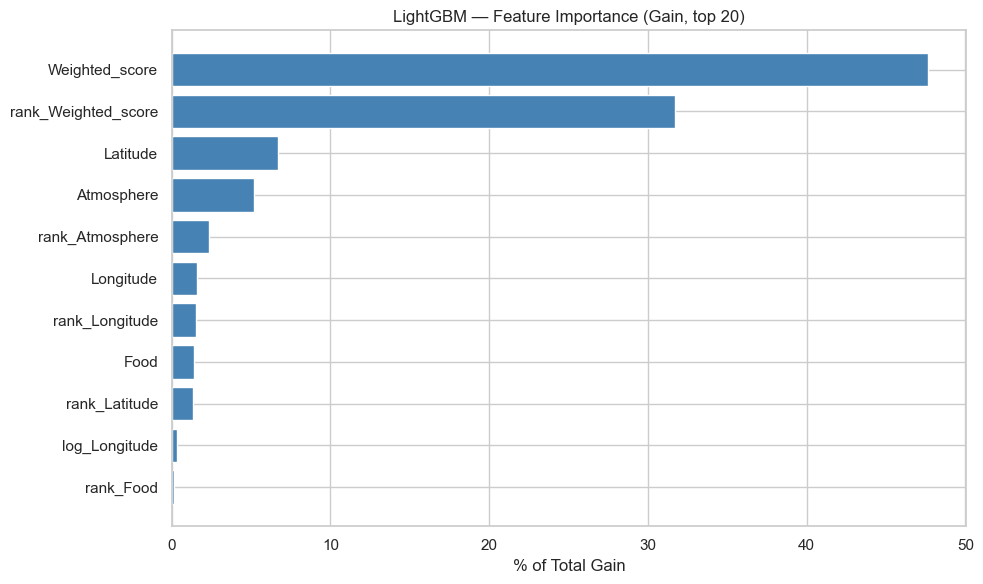

In [12]:
lgb_model.set_params(importance_type='gain')
lgb_model.fit(X_train_p, y_train)  # refit with gain importance

fi = pd.DataFrame({
    'feature'   : num_features[:X_train_p.shape[1]],
    'importance': lgb_model.feature_importances_[:len(num_features)]
}).sort_values('importance', ascending=False).head(20)

# Normalise to % of total gain
fi['importance_pct'] = fi['importance'] / fi['importance'].sum() * 100

print('Top features by gain importance:')
print(fi[['feature','importance_pct']].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi['feature'], fi['importance_pct'], color='steelblue')
ax.set_xlabel('% of Total Gain')
ax.set_title('LightGBM — Feature Importance (Gain, top 20)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Residual Analysis

Residuals should be:
1. **Centred at zero** — no systematic bias  
2. **Homoskedastic** — constant variance across predicted values  
3. **Approximately normal** — required for valid confidence intervals (less critical for RMSE optimisation)

Shapiro-Wilk tests normality (reliable up to n≈5000).


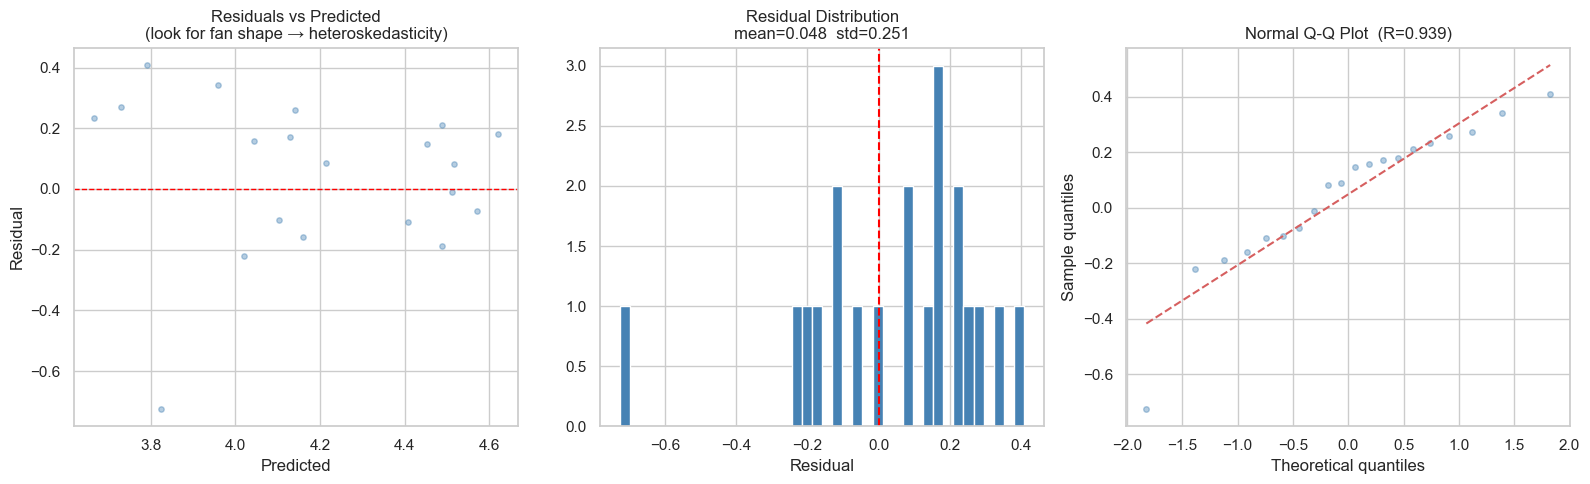

Shapiro-Wilk (n=20): W=0.8975  p=0.0370
→ Residuals deviate from normality — robust loss (Huber) may help.


In [13]:
y_pred_lgb = lgb_model.predict(X_test_p)
residuals   = y_test.values - y_pred_lgb

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_lgb, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted\n(look for fan shape → heteroskedasticity)')

# Residual histogram
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title(f'Residual Distribution\nmean={residuals.mean():.3f}  std={residuals.std():.3f}')

# QQ plot
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist='norm')
axes[2].plot(osm, osr, 'o', alpha=0.4, markersize=4, color='steelblue')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[2].set_title(f'Normal Q-Q Plot  (R={r:.3f})')
axes[2].set_xlabel('Theoretical quantiles')
axes[2].set_ylabel('Sample quantiles')

plt.tight_layout()
plt.show()

n_sw = min(len(residuals), 500)  # Shapiro-Wilk reliable up to ~5000
stat, p = shapiro(residuals[:n_sw])
print(f'Shapiro-Wilk (n={n_sw}): W={stat:.4f}  p={p:.4f}')
print('→ Residuals appear normal.' if p > 0.05
      else '→ Residuals deviate from normality — robust loss (Huber) may help.')

## 14. Error Stratification

Where does the model struggle most? We bin predictions and compute RMSE per bin — systematic errors in specific rating ranges reveal where the model can be improved.


RMSE by actual rating bin:
               n   RMSE    MAE
actual_bin                    
(3.098, 3.44]  1 0.7250 0.7250
(3.78, 4.12]   5 0.2063 0.1976
(4.12, 4.46]   8 0.2398 0.2152
(4.46, 4.8]    6 0.1359 0.1172


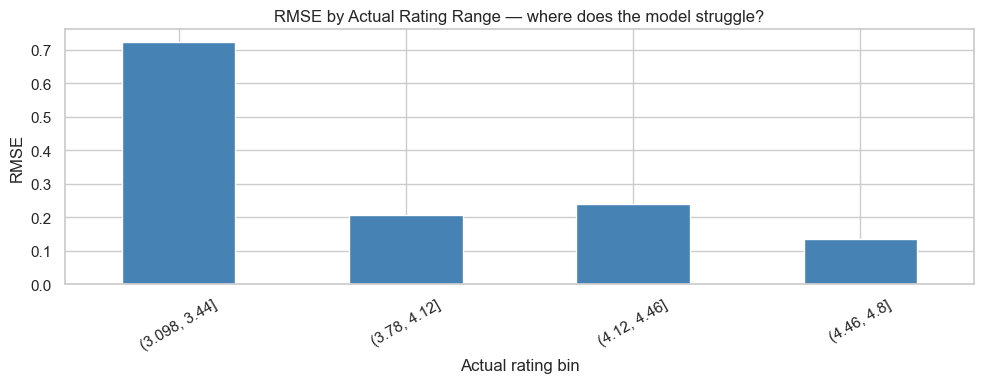

In [14]:
error_df = pd.DataFrame({
    'actual'   : y_test.values,
    'predicted': y_pred_lgb,
    'abs_error': np.abs(residuals)
})

# Bin by actual rating
error_df['actual_bin'] = pd.cut(error_df['actual'], bins=5)
bin_stats = error_df.groupby('actual_bin', observed=True).agg(
    n=('actual', 'count'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(4)

print('RMSE by actual rating bin:')
print(bin_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
bin_stats['RMSE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Actual rating bin')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Actual Rating Range — where does the model struggle?')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 15. Summary & Conclusions

### Results

| Model | CV RMSE | Test RMSE | Spearman ρ | Overfit gap |
|---|---|---|---|---|
| Baseline | *run* | *run* | *run* | — |
| Ridge | *run* | *run* | *run* | *run* |
| LightGBM | *run* | *run* | *run* | *run* |
| XGBoost | *run* | *run* | *run* | *run* |

*Fill in after running. Example: LightGBM: CV RMSE=0.38 ± 0.02, test RMSE=0.40, Spearman ρ=0.81, gap=+0.04*

### Key Takeaways

1. **Leakage check** — Food and Atmosphere are concurrent ratings. If they dominate feature importance, verify with the problem owner whether they are valid inputs.  
2. **Overfit gap** — *[e.g. LightGBM gap=0.04: acceptable / gap=0.15: reduce num_leaves or increase min_child_samples]*  
3. **Residuals** — *[e.g. slight left-skew in residuals; model over-predicts for very low rated restaurants — possible floor effect]*  
4. **Error stratification** — *[e.g. RMSE highest in 1.0–2.0 bin (n=12, rare class) — insufficient training data for extreme ratings]*  

### If Time Allows — Next Steps

- `RidgeCV` for automatic alpha selection  
- `Optuna` for LightGBM hyperparameter search with CV objective  
- Huber loss if residuals show heavy tails  
- Stacking: train a meta-learner on OOF predictions from Ridge + LightGBM  
